**This notebook will perform a dataset preprocessing and modeling**

In [32]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 1. Load Data

In [8]:
#Log transformed dataframe 
df = pd.read_csv("df_log.csv")

In [9]:
df

,ID,DIET,Exposure,Log Time,Breathing Frequency,Tidal volume,Inspiratory Time,Expiratory Time,Penh,Age,Time of Experiment
0,186,ND,Smog,0:00:00.2,6.503789,0.008211,0.035367,0.052592,0.198873,8 weeks,1st Buxco
1,186,ND,Smog,0:00:00.4,6.233380,0.007394,0.033435,0.080658,0.263445,8 weeks,1st Buxco
2,186,ND,Smog,0:00:00.5,6.549185,0.008309,0.033435,0.050693,0.059203,8 weeks,1st Buxco
3,186,ND,Smog,0:00:00.8,6.672632,0.009497,0.033435,0.041142,0.064034,8 weeks,1st Buxco
4,186,ND,Smog,0:00:01.0,6.526229,0.010930,0.039221,0.046884,0.072053,8 weeks,1st Buxco
...,...,...,...,...,...,...,...,...,...,...,...
646754,550,VDD,Smog,0:09:59.8,5.954840,0.033971,0.067659,0.082501,1.093290,18 weeks,Pre-Exposure
646755,550,VDD,Smog,0:09:59.9,5.942135,0.034319,0.065788,0.086178,1.167024,18 weeks,Pre-Exposure
646756,550,VDD,Smog,0:10:00.1,6.152201,0.033881,0.069526,0.054488,1.015688,18 weeks,Pre-Exposure
646757,550,VDD,Smog,0:10:00.2,6.216606,0.030833,0.056380,0.060154,1.163776,18 weeks,Pre-Exposure


### 2. Encode Categorical Variables

In [23]:
#One Hot Encode the categorical variable: EXposure
exposure_column = ["Exposure"]
encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
encoded_exposure = encoder.fit_transform(df[exposure_column])
encoded_df = pd.DataFrame(encoded_exposure, columns = encoder.get_feature_names_out(exposure_column))
numeric_encoded_df = pd.concat([df.drop(columns = exposure_column) , encoded_df], axis=1)

# Label Encode the Target Variable
le = LabelEncoder()
numeric_encoded_df["DIET"] = le.fit_transform(numeric_encoded_df["DIET"])

In [24]:
numeric_encoded_df

,ID,DIET,Log Time,Breathing Frequency,Tidal volume,Inspiratory Time,Expiratory Time,Penh,Age,Time of Experiment,Exposure_Air,Exposure_Smog,Exposure_Unknown
0,186,0,0:00:00.2,6.503789,0.008211,0.035367,0.052592,0.198873,8 weeks,1st Buxco,0.0,1.0,0.0
1,186,0,0:00:00.4,6.233380,0.007394,0.033435,0.080658,0.263445,8 weeks,1st Buxco,0.0,1.0,0.0
2,186,0,0:00:00.5,6.549185,0.008309,0.033435,0.050693,0.059203,8 weeks,1st Buxco,0.0,1.0,0.0
3,186,0,0:00:00.8,6.672632,0.009497,0.033435,0.041142,0.064034,8 weeks,1st Buxco,0.0,1.0,0.0
4,186,0,0:00:01.0,6.526229,0.010930,0.039221,0.046884,0.072053,8 weeks,1st Buxco,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
646754,550,1,0:09:59.8,5.954840,0.033971,0.067659,0.082501,1.093290,18 weeks,Pre-Exposure,0.0,1.0,0.0
646755,550,1,0:09:59.9,5.942135,0.034319,0.065788,0.086178,1.167024,18 weeks,Pre-Exposure,0.0,1.0,0.0
646756,550,1,0:10:00.1,6.152201,0.033881,0.069526,0.054488,1.015688,18 weeks,Pre-Exposure,0.0,1.0,0.0
646757,550,1,0:10:00.2,6.216606,0.030833,0.056380,0.060154,1.163776,18 weeks,Pre-Exposure,0.0,1.0,0.0


### 3. Finalized Dataset

In [27]:
final_df = numeric_endoded_df.iloc[:, [0,10, 11, 12,3,4,5,6,7,1]].copy()

In [28]:
final_df

,ID,Exposure_Air,Exposure_Smog,Exposure_Unknown,Breathing Frequency,Tidal volume,Inspiratory Time,Expiratory Time,Penh,DIET
0,186,0.0,1.0,0.0,6.503789,0.008211,0.035367,0.052592,0.198873,0
1,186,0.0,1.0,0.0,6.233380,0.007394,0.033435,0.080658,0.263445,0
2,186,0.0,1.0,0.0,6.549185,0.008309,0.033435,0.050693,0.059203,0
3,186,0.0,1.0,0.0,6.672632,0.009497,0.033435,0.041142,0.064034,0
4,186,0.0,1.0,0.0,6.526229,0.010930,0.039221,0.046884,0.072053,0
...,...,...,...,...,...,...,...,...,...,...
646754,550,0.0,1.0,0.0,5.954840,0.033971,0.067659,0.082501,1.093290,1
646755,550,0.0,1.0,0.0,5.942135,0.034319,0.065788,0.086178,1.167024,1
646756,550,0.0,1.0,0.0,6.152201,0.033881,0.069526,0.054488,1.015688,1
646757,550,0.0,1.0,0.0,6.216606,0.030833,0.056380,0.060154,1.163776,1


#### 4. Modeling

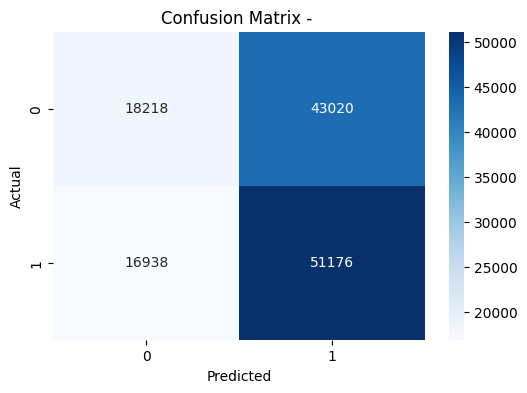


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.52      0.30      0.38     61238
           1       0.54      0.75      0.63     68114

    accuracy                           0.54    129352
   macro avg       0.53      0.52      0.50    129352
weighted avg       0.53      0.54      0.51    129352

Confusion Matrix:
[[18218 43020]
 [16938 51176]]
Accuracy: 0.5365

Top 3 Features:
Breathing Frequency: 0.1352
Tidal volume: -0.0749
Expiratory Time: 0.0687


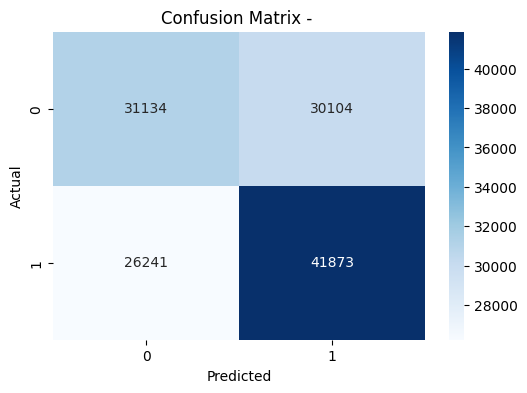


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.54      0.51      0.52     61238
           1       0.58      0.61      0.60     68114

    accuracy                           0.56    129352
   macro avg       0.56      0.56      0.56    129352
weighted avg       0.56      0.56      0.56    129352

Confusion Matrix:
[[31134 30104]
 [26241 41873]]
Accuracy: 0.5644

Top 3 Features:
Tidal volume: 0.3749
Penh: 0.3633
Breathing Frequency: 0.0922


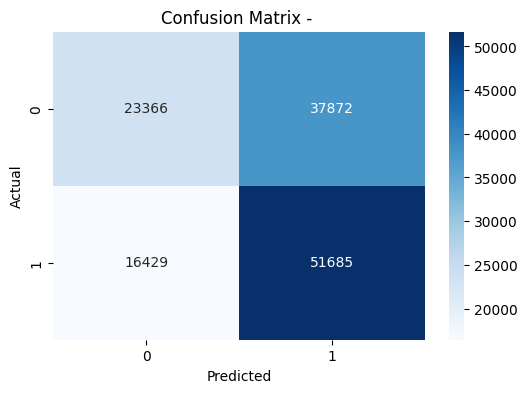


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.59      0.38      0.46     61238
           1       0.58      0.76      0.66     68114

    accuracy                           0.58    129352
   macro avg       0.58      0.57      0.56    129352
weighted avg       0.58      0.58      0.56    129352

Confusion Matrix:
[[23366 37872]
 [16429 51685]]
Accuracy: 0.5802

Top 3 Features:
Tidal volume: 0.3267
Inspiratory Time: 0.1815
Penh: 0.1183

Results saved to 'model_results.csv'


In [33]:
X = final_df.drop(columns = ["DIET","ID"])
y = final_df["DIET"]

# Split data
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


#Scale data
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Classifiers dictionary
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

feature_num = 3
    
# Train, predict, evaluate, and store results
trained_models = {}
results = []
for name, clf in classifiers.items():
    if name == "Logistic Regression":
        X_tr, X_tst = X_train_scaled, X_test_scaled
    else:
        X_tr, X_tst = X_train, X_test
            
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_tst)
    trained_models[name] = clf
    

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    report_text = classification_report(y_test, y_pred)  # For printing
    matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - ')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Get feature importance or coefficients
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
    elif hasattr(clf, "coef_"):
        importances = clf.coef_[0]
    else:
        importances = None

    # Top features (if available)
    top_features = None
    if importances is not None:
        top_features = sorted(
            zip(X.columns, importances), key=lambda x: abs(x[1]), reverse=True
        )[:feature_num] # change for num of features you want

    # Append results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Classification Report": report,
        "Confusion Matrix": matrix.tolist(),
        "Top Features": [(feature, round(imp, 4)) for feature, imp in top_features] if top_features else None
    })

    # Print summary
    print(f"\n=== {name} ===")
    print(report_text)  # Detailed classification report
    print(f"Confusion Matrix:\n{matrix}")
    print(f"Accuracy: {accuracy:.4f}")
    if top_features:
        print(f"\nTop {feature_num} Features:")
        for feature, importance in top_features:
            print(f"{feature}: {importance:.4f}")

    
results_df = pd.DataFrame([
    {
        "Model": result["Model"],
        "Accuracy": result["Accuracy"],
        "Confusion Matrix": result["Confusion Matrix"],
        "Top Features": result["Top Features"]
    }
    for result in results
])
results_df.to_csv("model_results.csv", index=False)

print("\nResults saved to 'model_results.csv'")



#### 5. Selecting Model for Streamlit

In [35]:
# Gradient Boosting had the highest accuracy
best_model = trained_models["Gradient Boosting"]

import pickle

# Save the pipeline to a file
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open("features.pkl", 'wb') as f:
    pickle.dump(X.columns.tolist(), f)